In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 12

# ==========================================
# 데이터 로드 및 전처리
# ==========================================
df = pd.read_csv("https://raw.githubusercontent.com/kzming2007/Catholic_ML_final_project/refs/heads/main/dataset/ur3_cobotops.csv")

# 결측치 제거
df_clean = df.dropna().copy()


##[1단계] 1차원 베이스라인 모델: Tool_current 단일 군집화

In [15]:
# 시계열 미반영 원칙에 따른 변수 분류 정리
# - 클러스터링 입력 가능: 순간 측정값 (Current, Speed, Temperature, Tool_current)
# - 클러스터링 입력 제외: 시간/순서 변수 (Timestamp, Num, cycle)
# - 사후 검증용으로만 사용: Bool 변수 (grip_lost, Robot_ProtectiveStop)

print(f"전체 데이터: {len(df)}행 → 결측치 제거 후: {len(df_clean)}행")
print(f"\n사용 가능한 연속형 변수 (순간 측정값):")

continuous_cols = [c for c in df_clean.columns
                   if c not in ['Num', 'Timestamp', 'cycle ', 'Robot_ProtectiveStop', 'grip_lost']]
for col in continuous_cols:
    print(f"  • {col}: {df_clean[col].min():.4f} ~ {df_clean[col].max():.4f}")

전체 데이터: 7409행 → 결측치 제거 후: 7355행

사용 가능한 연속형 변수 (순간 측정값):
  • Current_J0: -6.2478 ~ 6.8069
  • Temperature_T0: 27.8125 ~ 37.2500
  • Current_J1: -5.8087 ~ 1.0836
  • Temperature_J1: 29.3125 ~ 40.5000
  • Current_J2: -4.1720 ~ 2.4649
  • Temperature_J2: 29.3750 ~ 40.9375
  • Current_J3: -3.3331 ~ 2.2703
  • Temperature_J3: 32.1250 ~ 43.4375
  • Current_J4: -4.7384 ~ 4.0894
  • Temperature_J4: 32.2500 ~ 45.3750
  • Current_J5: -0.4746 ~ 0.3925
  • Temperature_J5: 32.0000 ~ 44.9375
  • Speed_J0: -0.6563 ~ 0.7919
  • Speed_J1: -0.3308 ~ 0.6155
  • Speed_J2: -2.7331 ~ 2.6798
  • Speed_J3: -1.2715 ~ 1.3631
  • Speed_J4: -0.2262 ~ 0.1939
  • Speed_J5: -1.6297 ~ 1.3780
  • Tool_current: 0.0202 ~ 0.6021


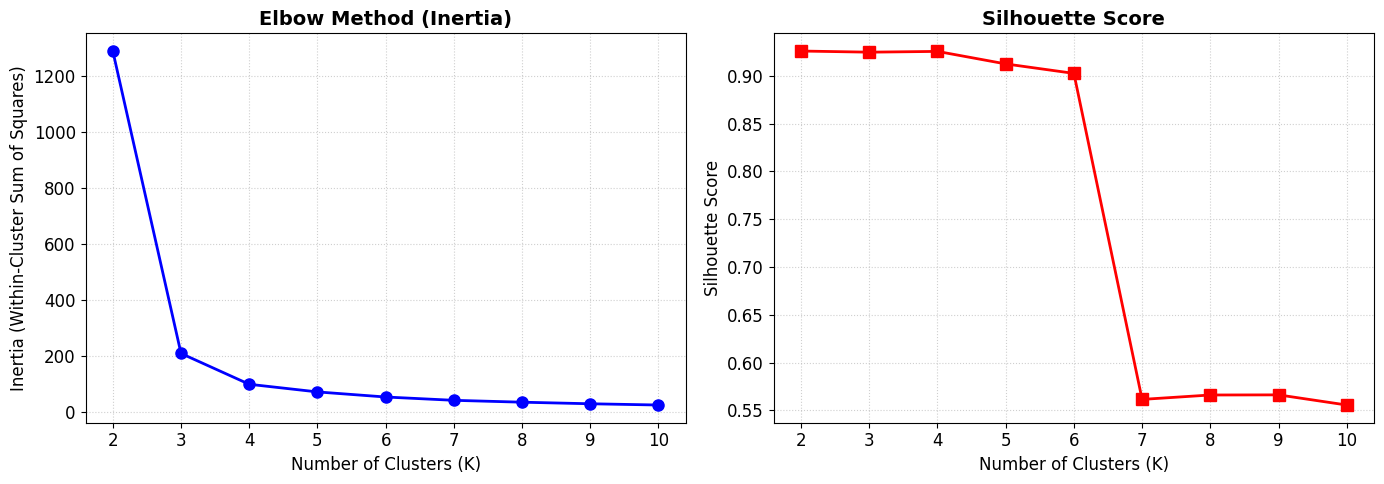


[K값별 실루엣 점수]
  K= 2 → Silhouette = 0.9260
  K= 3 → Silhouette = 0.9248 ◀ (삼봉 분포 기대)
  K= 4 → Silhouette = 0.9256
  K= 5 → Silhouette = 0.9125
  K= 6 → Silhouette = 0.9026
  K= 7 → Silhouette = 0.5615
  K= 8 → Silhouette = 0.5661
  K= 9 → Silhouette = 0.5663
  K=10 → Silhouette = 0.5556


In [16]:
# ==========================================
# [1단계] Tool_current 단일 변수 K-Means
# ==========================================
# 1차원이라도 StandardScaler를 적용하여 이후 단계(다차원 확장)와 동일한 파이프라인 유지
X_tool = df_clean[['Tool_current']].values
scaler = StandardScaler()
X_tool_scaled = scaler.fit_transform(X_tool)

# K = 2~10 범위에서 Inertia와 Silhouette Score 계산
K_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_tool_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_tool_scaled, labels))

# 시각화: Elbow + Silhouette 그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method (Inertia)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_xticks(list(K_range))
axes[0].grid(True, linestyle=':', alpha=0.6)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 결과 요약 출력
print("\n[K값별 실루엣 점수]")
for k, s in zip(K_range, silhouette_scores):
    marker = " ◀ (삼봉 분포 기대)" if k == 3 else ""
    print(f"  K={k:2d} → Silhouette = {s:.4f}{marker}")

In [17]:
# ==========================================
# K=3으로 최종 K-Means 학습
# ==========================================
# 논문에서 하중은 1kg, 2kg, 3kg 세 가지이므로 K=3이 물리적으로도 타당
optimal_k = 3

km_stage1 = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
df_clean['Cluster_Stage1'] = km_stage1.fit_predict(X_tool_scaled)

# 군집 라벨을 Tool_current 중심값(centroid) 기준으로 정렬하여 재할당
# → Cluster 0 = 가장 낮은 전류(저하중), Cluster 2 = 가장 높은 전류(고하중)
centroids = scaler.inverse_transform(km_stage1.cluster_centers_).flatten()
sorted_order = np.argsort(centroids)  # 오름차순 인덱스
label_map = {old: new for new, old in enumerate(sorted_order)}
df_clean['Cluster_Stage1'] = df_clean['Cluster_Stage1'].map(label_map)

# 재정렬된 중심값 출력
centroids_sorted = np.sort(centroids)
print("=== [1단계] Tool_current 단일 변수 K-Means (K=3) 결과 ===\n")
for i, c in enumerate(centroids_sorted):
    count = (df_clean['Cluster_Stage1'] == i).sum()
    print(f"  Cluster {i}: 중심 Tool_current = {c:.4f}A | 데이터 수 = {count:,}개")

sil = silhouette_score(X_tool_scaled, df_clean['Cluster_Stage1'])
print(f"\n  Silhouette Score = {sil:.4f}")

=== [1단계] Tool_current 단일 변수 K-Means (K=3) 결과 ===

  Cluster 0: 중심 Tool_current = 0.0848A | 데이터 수 = 6,339개
  Cluster 1: 중심 Tool_current = 0.1875A | 데이터 수 = 746개
  Cluster 2: 중심 Tool_current = 0.4746A | 데이터 수 = 270개

  Silhouette Score = 0.9248


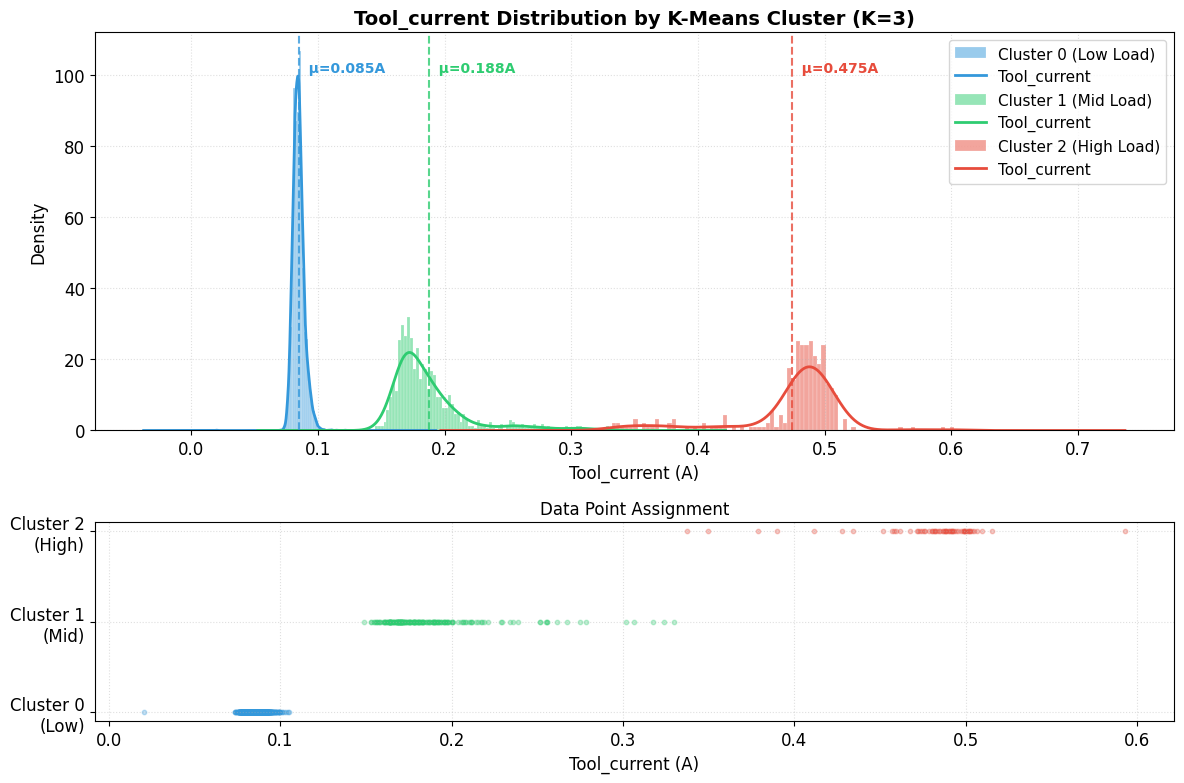

In [18]:
# ==========================================
# 시각화: Tool_current 분포 위에 군집 색상 표시
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [2, 1]})

cluster_colors = {0: '#3498db', 1: '#2ecc71', 2: '#e74c3c'}
cluster_labels = {0: 'Cluster 0 (Low Load)', 1: 'Cluster 1 (Mid Load)', 2: 'Cluster 2 (High Load)'}

# 상단: KDE + 히스토그램 (군집별 색상)
for c_id in sorted(df_clean['Cluster_Stage1'].unique()):
    subset = df_clean[df_clean['Cluster_Stage1'] == c_id]['Tool_current']
    axes[0].hist(subset, bins=80, alpha=0.5, color=cluster_colors[c_id],
                 label=cluster_labels[c_id], density=True, edgecolor='white', linewidth=0.3)
    subset.plot.kde(ax=axes[0], color=cluster_colors[c_id], linewidth=2)

# 중심점 표시
for i, c in enumerate(centroids_sorted):
    axes[0].axvline(x=c, color=cluster_colors[i], linestyle='--', linewidth=1.5, alpha=0.8)
    axes[0].text(c, axes[0].get_ylim()[1] * 0.9, f'  μ={c:.3f}A',
                 color=cluster_colors[i], fontsize=10, fontweight='bold')

axes[0].set_title('Tool_current Distribution by K-Means Cluster (K=3)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tool_current (A)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.4)

# 하단: Strip Plot (각 데이터 포인트의 군집 할당 시각화)
sample = df_clean.sample(n=min(2000, len(df_clean)), random_state=42)
for c_id in sorted(sample['Cluster_Stage1'].unique()):
    subset = sample[sample['Cluster_Stage1'] == c_id]
    axes[1].scatter(subset['Tool_current'], [c_id] * len(subset),
                    c=cluster_colors[c_id], alpha=0.3, s=10)

axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(['Cluster 0\n(Low)', 'Cluster 1\n(Mid)', 'Cluster 2\n(High)'])
axes[1].set_xlabel('Tool_current (A)')
axes[1].set_title('Data Point Assignment', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

In [19]:
# ==========================================
# 군집별 상세 통계 요약
# ==========================================
print("=== [1단계 결과] 군집별 Tool_current 통계 ===\n")
summary = df_clean.groupby('Cluster_Stage1')['Tool_current'].agg(['count', 'mean', 'std', 'min', 'max'])
summary.index.name = 'Cluster'
summary.columns = ['Count', 'Mean (A)', 'Std', 'Min (A)', 'Max (A)']
print(summary.round(4).to_string())

# ==========================================
# 1단계 한계점 정리 (2단계로의 전환 근거)
# ==========================================
print("\n" + "="*70)
print("[1단계 한계점 분석]")
print("="*70)
print("""
✅ 성공: Tool_current의 삼봉 분포를 3개의 군집으로 성공적으로 분리.
         → 논문의 3단계 하중(1kg, 2kg, 3kg)과 대응될 가능성 확인.

⚠️ 한계:
  1. 1차원 클러스터링은 수학적으로 '구간 나누기(Thresholding)'에 불과함.
     → K-Means의 다차원 거리 계산 장점을 활용하지 못함.
  2. 그리퍼 전류(Tool_current)만으로는 "로봇 팔 전체가 겪는 하중"을 대변하지 못함.
     → 하중을 직접 견디는 어깨(J1), 팔꿈치(J2) 관절의 전류 정보가 빠져 있음.

➡️ 2단계: Current_J1(어깨), Current_J2(팔꿈치)를 추가하여
         3차원 공간에서 군집화를 수행하고, 실루엣 점수 향상을 확인합니다.
""")

=== [1단계 결과] 군집별 Tool_current 통계 ===

         Count  Mean (A)     Std  Min (A)  Max (A)
Cluster                                           
0         6339    0.0848  0.0045   0.0202   0.1354
1          746    0.1875  0.0305   0.1449   0.3295
2          270    0.4746  0.0423   0.3321   0.6021

[1단계 한계점 분석]

✅ 성공: Tool_current의 삼봉 분포를 3개의 군집으로 성공적으로 분리.
         → 논문의 3단계 하중(1kg, 2kg, 3kg)과 대응될 가능성 확인.

⚠️ 한계:
  1. 1차원 클러스터링은 수학적으로 '구간 나누기(Thresholding)'에 불과함.
     → K-Means의 다차원 거리 계산 장점을 활용하지 못함.
  2. 그리퍼 전류(Tool_current)만으로는 "로봇 팔 전체가 겪는 하중"을 대변하지 못함.
     → 하중을 직접 견디는 어깨(J1), 팔꿈치(J2) 관절의 전류 정보가 빠져 있음.

➡️ 2단계: Current_J1(어깨), Current_J2(팔꿈치)를 추가하여
         3차원 공간에서 군집화를 수행하고, 실루엣 점수 향상을 확인합니다.



##[2단계] — 다차원 모델 고도화: 어깨/팔꿈치 전류 추가

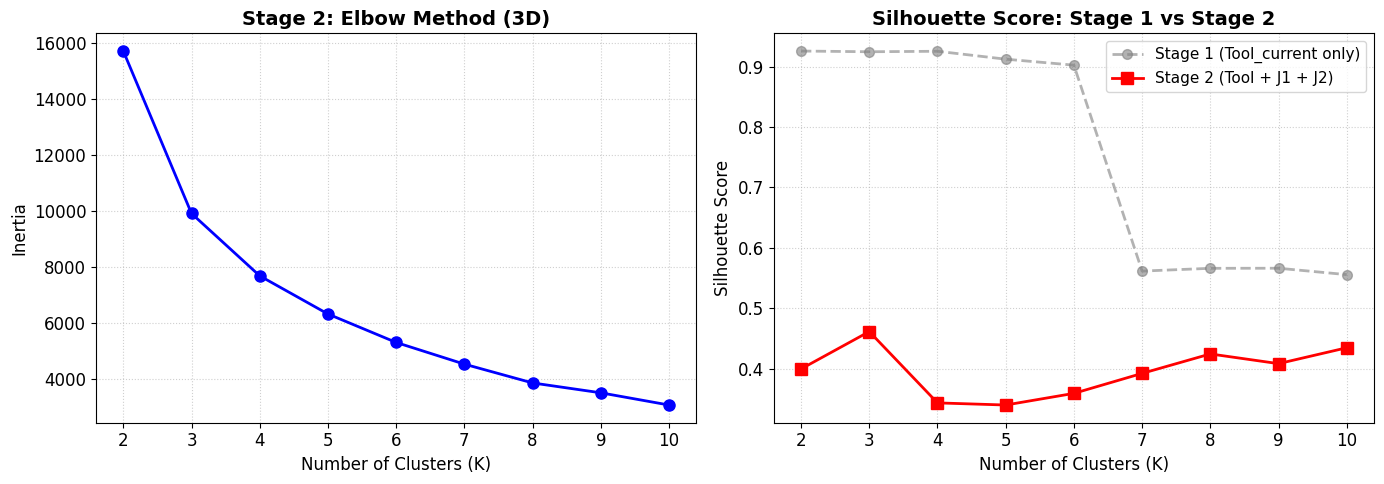


[K값별 실루엣 점수 비교: 1단계 vs 2단계]
   K |   Stage 1 (1D) |   Stage 2 (3D) |       변화
--------------------------------------------------
   2 |         0.9260 |         0.3995 | ▼ 0.5265
   3 |         0.9248 |         0.4614 | ▼ 0.4635
   4 |         0.9256 |         0.3432 | ▼ 0.5824
   5 |         0.9125 |         0.3397 | ▼ 0.5729
   6 |         0.9026 |         0.3590 | ▼ 0.5436
   7 |         0.5615 |         0.3921 | ▼ 0.1694
   8 |         0.5661 |         0.4243 | ▼ 0.1418
   9 |         0.5663 |         0.4082 | ▼ 0.1580
  10 |         0.5556 |         0.4345 | ▼ 0.1211


In [20]:
# ==========================================
# [2단계] 다차원 확장: Tool_current + Current_J1(어깨) + Current_J2(팔꿈치)
# ==========================================
# 논문 근거: ANOVA 분석 결과 '하중(Workload)'이 에러의 가장 큰 요인이며,
#           하중은 특히 Current_J1(어깨)과 Current_J2(팔꿈치)에 가장 큰 영향을 줌.
#           → 이 두 관절이 로봇 팔의 무게를 직접 지탱하기 때문.

stage2_features = ['Tool_current', 'Current_J1', 'Current_J2']
X_stage2 = df_clean[stage2_features].values

# 다차원 클러스터링에서는 변수 간 스케일 차이가 거리 계산에 영향을 주므로
# StandardScaler 적용이 필수적 (1단계와 동일한 파이프라인 유지)
scaler_s2 = StandardScaler()
X_stage2_scaled = scaler_s2.fit_transform(X_stage2)

# K = 2~10 범위에서 성능 비교
K_range = range(2, 11)
inertias_s2 = []
silhouette_scores_s2 = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_stage2_scaled)
    inertias_s2.append(km.inertia_)
    silhouette_scores_s2.append(silhouette_score(X_stage2_scaled, labels))

# 시각화: 1단계 vs 2단계 Silhouette Score 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method (2단계)
axes[0].plot(K_range, inertias_s2, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Stage 2: Elbow Method (3D)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_range))
axes[0].grid(True, linestyle=':', alpha=0.6)

# Silhouette Score: 1단계 vs 2단계 비교
axes[1].plot(K_range, silhouette_scores, 'o--', linewidth=2, markersize=7,
             color='gray', alpha=0.6, label='Stage 1 (Tool_current only)')
axes[1].plot(K_range, silhouette_scores_s2, 'rs-', linewidth=2, markersize=8,
             label='Stage 2 (Tool + J1 + J2)')
axes[1].set_title('Silhouette Score: Stage 1 vs Stage 2', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 결과 요약 출력
print("\n[K값별 실루엣 점수 비교: 1단계 vs 2단계]")
print(f"{'K':>4} | {'Stage 1 (1D)':>14} | {'Stage 2 (3D)':>14} | {'변화':>8}")
print("-" * 50)
for k, s1, s2 in zip(K_range, silhouette_scores, silhouette_scores_s2):
    diff = s2 - s1
    arrow = "▲" if diff > 0 else "▼" if diff < 0 else "="
    print(f"  {k:2d} | {s1:14.4f} | {s2:14.4f} | {arrow} {abs(diff):.4f}")

In [21]:
# ==========================================
# K=3으로 2단계 K-Means 학습
# ==========================================
optimal_k = 3

km_stage2 = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
df_clean['Cluster_Stage2'] = km_stage2.fit_predict(X_stage2_scaled)

# 군집 라벨을 Tool_current 중심값 기준으로 정렬 (1단계와 동일한 기준)
# → Cluster 0 = 저하중, Cluster 2 = 고하중
centroids_s2_scaled = km_stage2.cluster_centers_
centroids_s2 = scaler_s2.inverse_transform(centroids_s2_scaled)

# Tool_current 열(인덱스 0)의 중심값 기준 오름차순 정렬
sorted_order_s2 = np.argsort(centroids_s2[:, 0])
label_map_s2 = {old: new for new, old in enumerate(sorted_order_s2)}
df_clean['Cluster_Stage2'] = df_clean['Cluster_Stage2'].map(label_map_s2)

# 재정렬된 중심값 출력
centroids_s2_sorted = centroids_s2[sorted_order_s2]
sil_s2 = silhouette_score(X_stage2_scaled, df_clean['Cluster_Stage2'])

print("=== [2단계] Tool + J1 + J2  3차원 K-Means (K=3) 결과 ===\n")
print(f"{'Cluster':>10} | {'Tool_current':>14} | {'Current_J1':>12} | {'Current_J2':>12} | {'Count':>8}")
print("-" * 70)
for i, c in enumerate(centroids_s2_sorted):
    count = (df_clean['Cluster_Stage2'] == i).sum()
    print(f"{'Cluster '+str(i):>10} | {c[0]:14.4f}A | {c[1]:12.4f}A | {c[2]:12.4f}A | {count:8,}개")

print(f"\n  2단계 Silhouette Score = {sil_s2:.4f}")
print(f"  1단계 Silhouette Score = {sil:.4f}")
print(f"  변화: {'▲' if sil_s2 > sil else '▼'} {abs(sil_s2 - sil):.4f}")

=== [2단계] Tool + J1 + J2  3차원 K-Means (K=3) 결과 ===

   Cluster |   Tool_current |   Current_J1 |   Current_J2 |    Count
----------------------------------------------------------------------
 Cluster 0 |         0.0862A |      -3.3622A |      -1.9574A |    1,467개
 Cluster 1 |         0.0973A |      -2.0374A |      -1.0158A |    5,596개
 Cluster 2 |         0.4616A |      -1.9576A |      -0.9183A |      292개

  2단계 Silhouette Score = 0.4614
  1단계 Silhouette Score = 0.9248
  변화: ▼ 0.4635


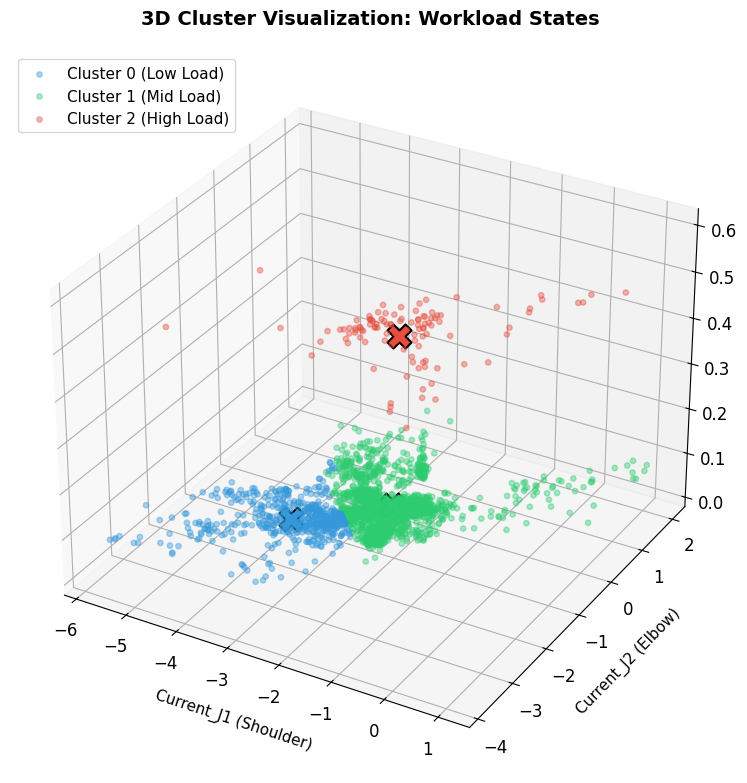

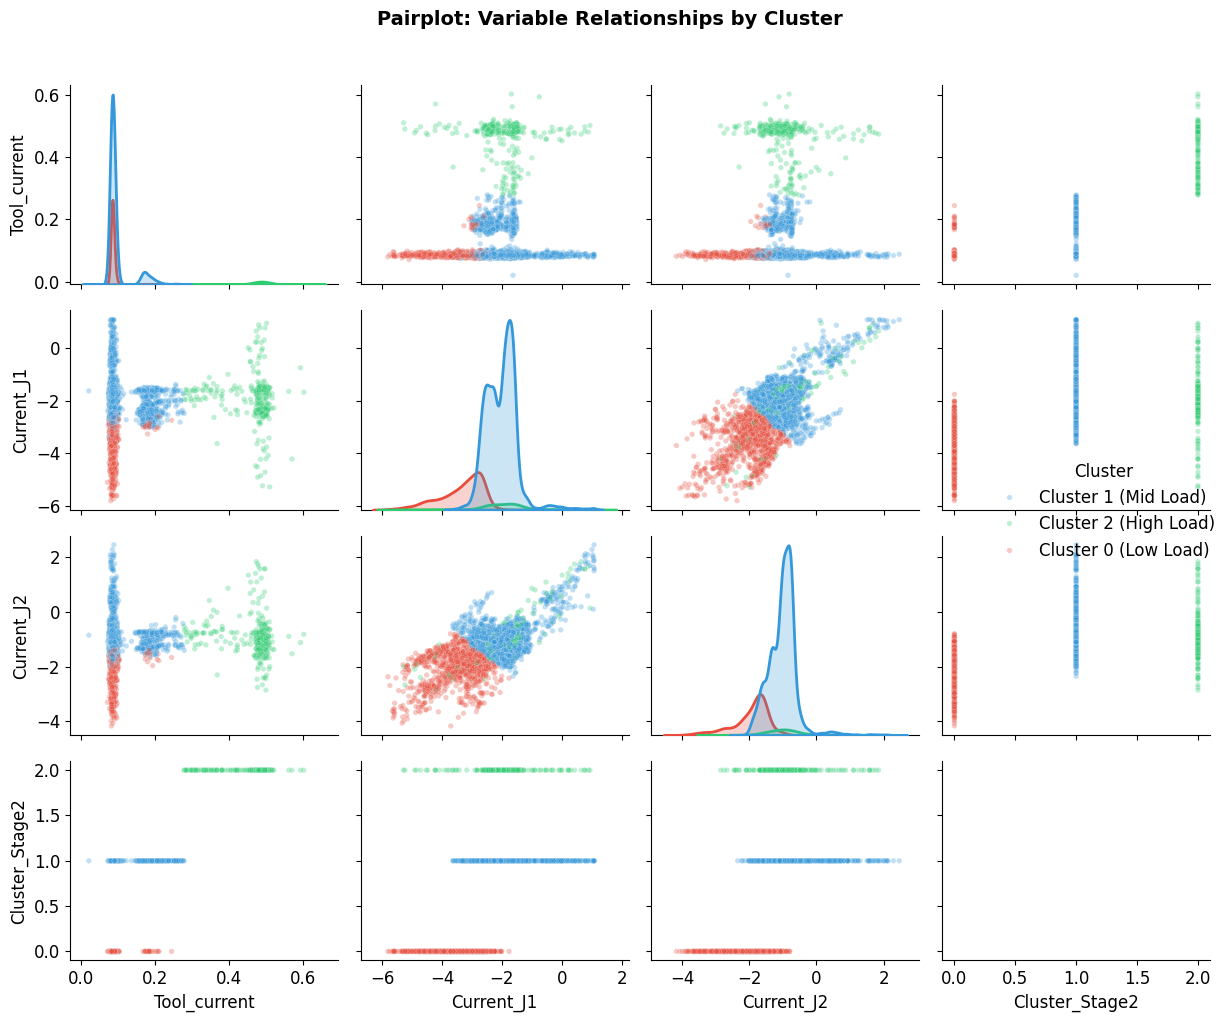

In [22]:
# ==========================================
# 시각화 1: 3D Scatter Plot (군집별 색상)
# ==========================================
from mpl_toolkits.mplot3d import Axes3D

cluster_colors = {0: '#3498db', 1: '#2ecc71', 2: '#e74c3c'}
cluster_labels_s2 = {0: 'Cluster 0 (Low Load)', 1: 'Cluster 1 (Mid Load)', 2: 'Cluster 2 (High Load)'}

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 샘플링 (전체 데이터가 너무 많으면 렌더링이 느림)
sample = df_clean.sample(n=min(3000, len(df_clean)), random_state=42)

for c_id in sorted(sample['Cluster_Stage2'].unique()):
    subset = sample[sample['Cluster_Stage2'] == c_id]
    ax.scatter(subset['Current_J1'], subset['Current_J2'], subset['Tool_current'],
               c=cluster_colors[c_id], alpha=0.4, s=15, label=cluster_labels_s2[c_id])

# 중심점 표시 (크고 뚜렷하게)
for i, c in enumerate(centroids_s2_sorted):
    ax.scatter(c[1], c[2], c[0], c=cluster_colors[i], s=300, marker='X',
               edgecolors='black', linewidths=1.5, zorder=10)

ax.set_xlabel('Current_J1 (Shoulder)', fontsize=11, labelpad=10)
ax.set_ylabel('Current_J2 (Elbow)', fontsize=11, labelpad=10)
ax.set_zlabel('Tool_current (Gripper)', fontsize=11, labelpad=10)
ax.set_title('3D Cluster Visualization: Workload States', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()


# ==========================================
# 시각화 2: Pairplot (변수 간 관계 + 군집 색상)
# ==========================================
# Pairplot용 데이터프레임 준비
plot_df = df_clean[['Tool_current', 'Current_J1', 'Current_J2', 'Cluster_Stage2']].copy()
plot_df['Cluster'] = plot_df['Cluster_Stage2'].map(cluster_labels_s2)

g = sns.pairplot(
    plot_df, hue='Cluster',
    palette=[cluster_colors[0], cluster_colors[1], cluster_colors[2]],
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 15},
    diag_kws={'linewidth': 2}
)
g.figure.suptitle('Pairplot: Variable Relationships by Cluster', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# ==========================================
# 군집별 상세 통계 요약 (3개 변수 모두)
# ==========================================
print("=== [2단계 결과] 군집별 3변수 통계 ===\n")

for feature in stage2_features:
    print(f"\n--- {feature} ---")
    summary = df_clean.groupby('Cluster_Stage2')[feature].agg(['count', 'mean', 'std', 'min', 'max'])
    summary.index.name = 'Cluster'
    summary.columns = ['Count', 'Mean', 'Std', 'Min', 'Max']
    print(summary.round(4).to_string())

# ==========================================
# 1단계 vs 2단계 군집 할당 교차 비교
# ==========================================
print("\n" + "="*70)
print("[1단계 vs 2단계 군집 할당 교차표 (Crosstab)]")
print("="*70)
ct = pd.crosstab(
    df_clean['Cluster_Stage1'],
    df_clean['Cluster_Stage2'],
    rownames=['Stage 1'],
    colnames=['Stage 2']
)
print(ct)

print(f"""
[해석]
• 교차표에서 대각선 값이 클수록 두 단계의 군집 할당이 일치함을 의미합니다.
• 대각선 외의 값은 어깨/팔꿈치 전류를 추가함으로써 "재분류"된 데이터 포인트입니다.
• 재분류된 포인트가 많다면, 1단계(1D)에서는 구분하지 못했던 하중 상태를
  2단계(3D)에서 더 세밀하게 분리했음을 의미합니다.
""")

# ==========================================
# 2단계 정리 (3단계로의 전환 근거)
# ==========================================
print("="*70)
print("[2단계 분석 정리]")
print("="*70)
print(f"""
📊 1단계 → 2단계 성능 변화:
   • Silhouette: {sil:.4f} → {sil_s2:.4f} ({'향상 ▲' if sil_s2 > sil else '하락 ▼'} {abs(sil_s2 - sil):.4f})

💡 핵심 인사이트:
   • Current_J1(어깨)과 Current_J2(팔꿈치)를 추가함으로써 군집의 물리적 해석이 풍부해짐.
   • 어깨와 팔꿈치는 로봇 팔의 하중을 직접 지탱하는 핵심 관절.
   • 3D Scatter Plot에서 군집이 공간상으로 분리된 모습을 확인.

➡️ 3단계: 이렇게 분류된 하중 군집이 실제로 로봇의 "온도"에 어떤 영향을 미치는지,
         그리고 시스템 에러(grip_lost)와 어떤 관계가 있는지 검증합니다.
""")

=== [2단계 결과] 군집별 3변수 통계 ===


--- Tool_current ---
         Count    Mean     Std     Min     Max
Cluster                                       
0         1467  0.0862  0.0133  0.0706  0.2442
1         5596  0.0973  0.0341  0.0202  0.2785
2          292  0.4616  0.0613  0.2781  0.6021

--- Current_J1 ---
         Count    Mean     Std     Min     Max
Cluster                                       
0         1467 -3.3617  0.7211 -5.8087 -1.7661
1         5596 -2.0368  0.5398 -3.6470  1.0836
2          292 -1.9576  0.9152 -5.2852  0.9388

--- Current_J2 ---
         Count    Mean     Std     Min     Max
Cluster                                       
0         1467 -1.9557  0.5446 -4.1720 -0.7945
1         5596 -1.0158  0.4426 -2.3472  2.4649
2          292 -0.9183  0.7289 -2.8552  1.8505

[1단계 vs 2단계 군집 할당 교차표 (Crosstab)]
Stage 2     0     1    2
Stage 1                 
0        1445  4894    0
1          22   702   22
2           0     0  270

[해석]
• 교차표에서 대각선 값이 클수록 두 단계의 군집 할당이 일치함을 의